In [122]:
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
words = open('names.txt','r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [5]:
# vocabulary of charaters
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)} #map char:integer form 1
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [6]:
#building the dataset of the model
# the model is learning based on a context, the last n character ecountered before, in this way whe choose a context lenght size
block_size = 3 #context_lenght
#we build the dataset from our data: the first block_size character followed by the target character, for each word,
# example for the word emma we want
#  X  ----> Y
# ... ----> e
# ..e ----> m
# .em ----> m
# emm ----> a
# mma ----> .
# the value must be the integer as the model can only be trained on numbers
# the dot is used as padding
X , Y = [], []
for w in words:
    # print(w)
    context = [0]*block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[c] for c in context), '---->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [7]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [ ]:
# the approces used in the paper is based on word-level where they embedded the context of word
# in to ac space to small dimension
# weare modelling a charchter level - so we have an input based on the vocabolary of the 27 chars e we choose an embedde dim of 2
C = torch.randn(27,2)
# we use the pytorch indexing. we want the embedding on the input, where each input isa a block of char so we che use
emb = C[X] # in this way we get for each colom of X that was a char the correspond embedding of C
# es. 
# print(X[13,2])
# C[X[13,2]]
emb.shape

torch.Size([32, 3, 2])

In [44]:
# for the hidden layer we need choose a dimension that we want to learn, fro example 100
# for each of the input that isa a 3*2 the embedding for each context_lenght
W1 = torch.randn(6, 100)
b1 = torch.randn(100)
# but to apply mat mul of emb @ W1 wee need to take the dim of emb to 6 because they are
# ([32, 3, 2]) * [(6, 100)]
# to this we can concat all the embedding to the 1 dimension (the dimension strat from 1)
# torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1).shape
# torch.Size([32, 6])
# this kind of index doesn't scale well if we want to change the context lenght, so intesad we canuse unbind
# torch.unbind delete on their own a specific dimension to give you a list/tensor of element without that
# torch.cat(torch.unbind(emb,1), 1).shape
# there is a simple and best way that is with view
# emb.view(32, 6)
# h = emb.view(32, 6) @ W1 + b1
# h.shape
# but we don't want to specify the size of 32 because it can change so we can use
# emb.view(emb.shape[0], 6)
# or a better way that is emb.view(-1, 6), -1 tall to tensor to infer that alone to mantain the shape o 6
h = torch.tanh(emb.view(32, 6) @ W1 + b1) 
h.shape

torch.Size([32, 100])

In [ ]:
# the second layer - the input dim in the otput dim of the first layer, the output dim the number of vocabolary in which we apply softmax fro porbability distribution
W2 = torch.randn(100,27)
b2 = torch.randn(27)

In [47]:
logits = h @ W2 + b2

In [48]:
logits.shape

torch.Size([32, 27])

In [53]:
# softmax
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
# sum(prob[1]) # each row is normalized
prob.shape


torch.Size([32, 27])

In [ ]:
# we want the probabilty for the next charcter that defined by Y
# for each input of prob we look at the character Y prob[torch.arange(32),Y]
# we use the loss fucntion of negative log likelihood
loss = -prob[torch.arange(32),Y].log().mean()
# in a simplier command, in the case of classificarion task
F.cross_entropy(logits,Y)

In [116]:
#rewriting the code
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [9]:
#number of pam
sum (p.nelement() for p in parameters)

3481

In [ ]:
# foward pass
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
# backward pass
# first we set the gradint to be zero
for p in parameters:
    p.grad = None # equivalent to setting to zero
loss.backward() # to populate these gradients
# update 
for p in parameters:
    p.data += -0.1 * p.grad #updating de parameters for the learning rate

In [11]:
# setting the real training just taking the code above adn duing for tot step
for p in parameters:
    p.requires_grad = True

for _ in range(10):
    # foward pass
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    # backward pass
    # first we set the gradint to be zero
    for p in parameters:
        p.grad = None # equivalent to setting to zero
    loss.backward() # to populate these gradients
    # update 
    for p in parameters:
        p.data += -0.1 * p.grad #updating de parameters for the learning rate

10.709586143493652
10.407631874084473
10.127808570861816
9.864365577697754
9.614501953125
9.376439094543457
9.148944854736328
8.931110382080078
8.722230911254883
8.521748542785645


In [ ]:
#let's do in batch that means random selecting a portion of the dataset each time
torch.randint(0, X.shape[0], (32,))

tensor([153325, 226689, 189287,  88611, 170077, 126823, 127447, 176293,   3778,
        184519, 101451, 114777,   4152, 153899, 105884, 185941, 155236, 101357,
        133366, 200749, 203565,  34610,  92185, 116410, 141159, 113965, 191769,
        142618, 190425, 153103, 102324,  83114])

In [ ]:
for _ in range(1000):

    ix = torch.randint(0, X.shape[0], (32,)) # random idex of the batch
    # foward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    # backward pass
    # first we set the gradint to be zero
    for p in parameters:
        p.grad = None # equivalent to setting to zero
    loss.backward() # to populate these gradients
    # update 
    for p in parameters:
        p.data += -0.1 * p.grad #updating de parameters for the learning rate
print(loss.item())
# the fact is the calculating the gradient of a portion of the dataset instead of the entire is faster and an approssimation of that, but step by step is the same

2.3763327598571777


In [ ]:
# the print now is the acutualloss of the batch, let's print of the entire dataset
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
print(loss.item())

2.5540823936462402


In [115]:
# we can see setting differnt order on the fly from -0.01 or 0.1 or 1 or 10 and we see that at 10 it explode the loss doesn't go down
#  so is some way looking the loss that decrease we want to go from -00.1 to -1
# we can use linspace that are 1000 number for 0.01 to 1 taken linearnly
lre = torch.linspace(0.01, 1, 1000)
# but we prefer taking the steps exponentially
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre #so exponentially from 10**-3 and 10**0 --> 0.01 and 1
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [127]:
#rewriting the code
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [125]:
# so we run for the i learning rate tha we generated and we take trace of the loss
lri = []
lossi = []
for i in range(1000):

    ix = torch.randint(0, X.shape[0], (32,)) # random idex of the batch
    # foward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())
    # backward pass
    # first we set the gradint to be zero
    for p in parameters:
        p.grad = None # equivalent to setting to zero
    loss.backward() # to populate these gradients
    # update 
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad #updating de parameters for the learning rate
    # track stars
    lri.append(lre[i])
    lossi.append(loss.item())
# print(loss.item())

22.592561721801758
19.373741149902344
22.247827529907227
21.185224533081055
17.265350341796875
17.656322479248047
18.805377960205078
16.838760375976562
19.095375061035156
17.779489517211914
18.86737060546875
19.950773239135742
21.051372528076172
17.99334716796875
17.663331985473633
18.634822845458984
18.328824996948242
21.16509246826172
20.28922462463379
17.618000030517578
19.18478775024414
19.044322967529297
19.046192169189453
19.330121994018555
19.822586059570312
19.019184112548828
17.0107364654541
14.320420265197754
18.809085845947266
17.480941772460938
16.946016311645508
15.08208179473877
17.269256591796875
17.718019485473633
19.374841690063477
20.710861206054688
18.452516555786133
19.507230758666992
17.481714248657227
20.15323829650879
20.38865852355957
19.778776168823242
20.259807586669922
18.58316421508789
16.4687557220459
18.1898250579834
19.148473739624023
18.925813674926758
16.247283935546875
15.604716300964355
17.609323501586914
19.949607849121094
12.923314094543457
19.33758

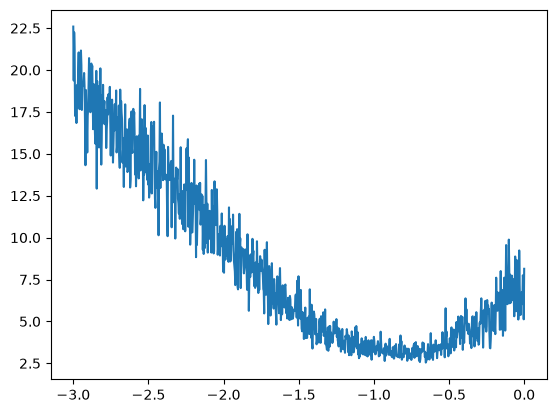

In [ ]:
# we plot on the x ax the exponent of learning rate e in y le loss for that learning rate
plt.plot(lri, lossi)

In [ ]:
#we look that the good learning rate is for -1.0 so 10**-1.0 so it's 0.1

In [136]:
lri = []
lossi = []
for i in range(10000):

    ix = torch.randint(0, X.shape[0], (32,)) # random idex of the batch
    # foward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    # print(loss.item())

    # backward pass
    # first we set the gradint to be zero
    for p in parameters:
        p.grad = None # equivalent to setting to zero
    loss.backward() # to populate these gradients

    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad #updating de parameters for the learning rate

    # track stars
    # lri.append(lre[i])
    # lossi.append(loss.item())
    
# print(loss.item())

In [ ]:
# the print before is the acutualloss of the batch, let's print of the entire dataset
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
print(loss.item())

2.3083035945892334


In [ ]:
# a sentimeno lancialo 10k step di training e misuriamo la loss con un learning rate fisso
# ad un certo punto, dopo 3 iterazioni, la loss è circa quella abbiamo raggiunto il plateau per tanto andiamo di piccoli passi
# con weigh decay, abbiamo gli step di un ordine di grandezza

# let do the train split / validation split / test split
# the train data is used for memorizime from that and learning
# the validation for change the hyperparameters (numer of param of a state, regularization step)
# test the real performance to unseen data

In [138]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
# 80% train and 10%dev/validation and 10%test
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [139]:
#rewriting the code
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [143]:
# so this now is done on Xtr e Ytr
lri = []
lossi = []
for i in range(10000):

    ix = torch.randint(0, Xtr.shape[0], (32,)) # random idex of the batch
    # foward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass
    # first we set the gradint to be zero
    for p in parameters:
        p.grad = None # equivalent to setting to zero
    loss.backward() # to populate these gradients

    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad #updating de parameters for the learning rate

    # track stars
    # lri.append(lre[i])
    # lossi.append(loss.item())
    
print(loss.item())

2.1295433044433594


In [144]:
# print of the loss on the dev/test set
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.277327537536621


In [ ]:
# we can see also the loss on the train
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

2.2731263637542725


In [ ]:
# the train and the test loss are the same so we are in underfitting
# that means that the network is small
# so we increase the size scaling up
#rewriting the code
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

#number of pam
sum (p.nelement() for p in parameters)

10281

In [151]:
for p in parameters:
    p.requires_grad = True

In [165]:
# so this now is done on Xtr e Ytr
lri = []
lossi = []
stepi = []
for i in range(30000):

    ix = torch.randint(0, Xtr.shape[0], (32,)) # random idex of the batch
    # foward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass
    # first we set the gradint to be zero
    for p in parameters:
        p.grad = None # equivalent to setting to zero
    loss.backward() # to populate these gradients

    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad #updating de parameters for the learning rate

    # track stars
    # lri.append(lre[i])
    lossi.append(loss.item())
    stepi.append(i)
    
# print(loss.item())

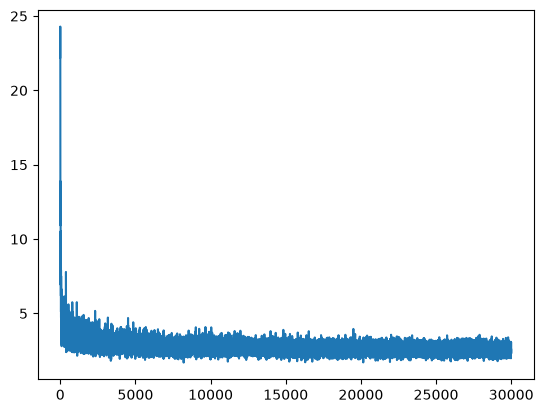

In [154]:
plt.plot(stepi, lossi)

In [ ]:
#we can see the noise beacause is the loss per step in the batch that is the approximation

In [183]:
# print of the loss on the dev/test set
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

2.32271671295166


In [167]:
# print of the loss on the dev/test set
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.243494749069214


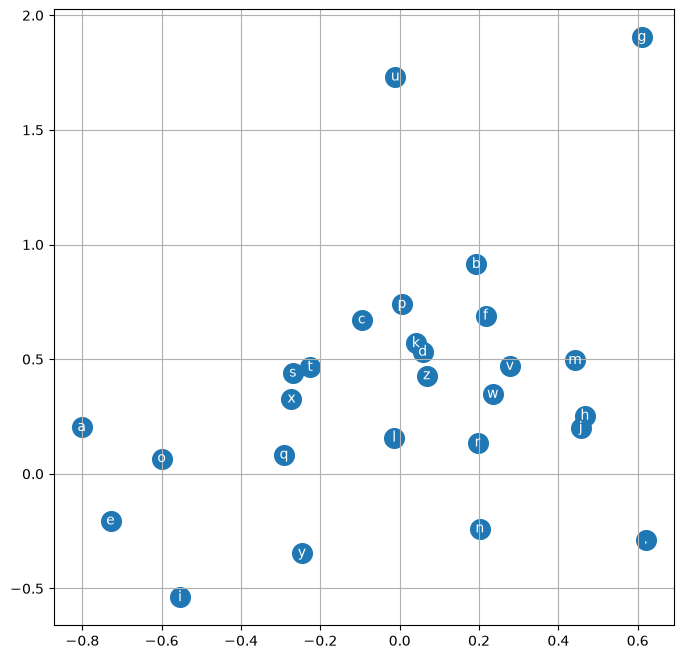

In [ ]:
# the two loss are the same and train doesn't go down so the bottlwneck is the 2 dim embedding size
# let's visualize the embedding learned by the net
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [176]:
#we can see that the vowels are near so they are in some way interchangeable for the net, make sense, and we can se also
# some cluster for the other some structure
# so we increase the emb size to 10 dim 
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g)
W1 = torch.randn((30,200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

#number of pam
sum (p.nelement() for p in parameters)

11897

In [177]:
for p in parameters:
    p.requires_grad = True

In [178]:
lri = []
lossi = []
stepi = []

In [190]:
for i in range(50000):

    ix = torch.randint(0, Xtr.shape[0], (32,)) # random idex of the batch
    # foward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass
    # first we set the gradint to be zero
    for p in parameters:
        p.grad = None # equivalent to setting to zero
    loss.backward() # to populate these gradients

    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad #updating de parameters for the learning rate

    # track stars
    # lri.append(lre[i])
    # we use log loss to put the plot readable
    lossi.append(loss.log10().item())
    stepi.append(i)
    
# print(loss.item())

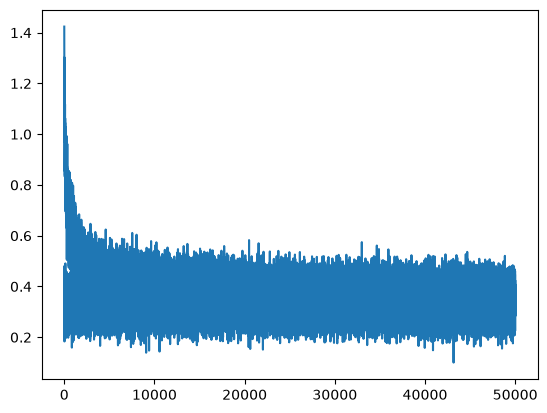

In [191]:
plt.plot(stepi, lossi)

In [192]:
# print of the loss on the tr set
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

2.1681973934173584


In [193]:
# print of the loss on the dev/test set
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.199216365814209


In [194]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmahela.
jha.
khirmyn.
rehty.
salaysa.
jazhnelle.
elynci.
geni.
neriana.
chaiir.
kaleigh.
ham.
jorniquint.
sroi.
rai.
addi.
watell.
dearyni.
jaceelinsleye.
dedi.
